In [2]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [6]:
data = pd.read_csv('insurance.csv')
df = data.copy(deep=True)

In [8]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [10]:
df.shape

(1338, 7)

In [20]:
df.describe(include='O')

,sex,smoker,region
count,1338,1338,1338
unique,2,2,4
top,male,no,southeast
freq,676,1064,364


In [18]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

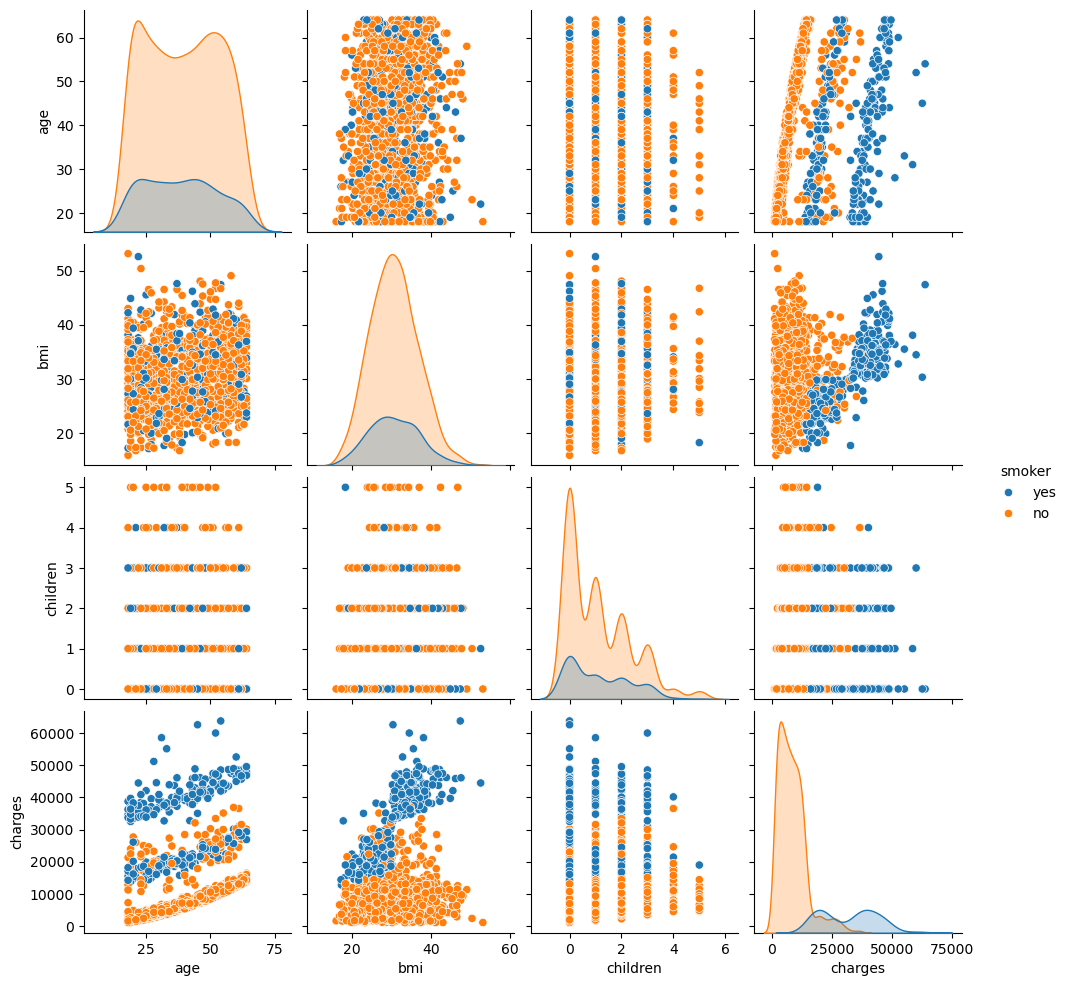

In [36]:
sns.pairplot(df, hue= 'smoker')
plt.show()

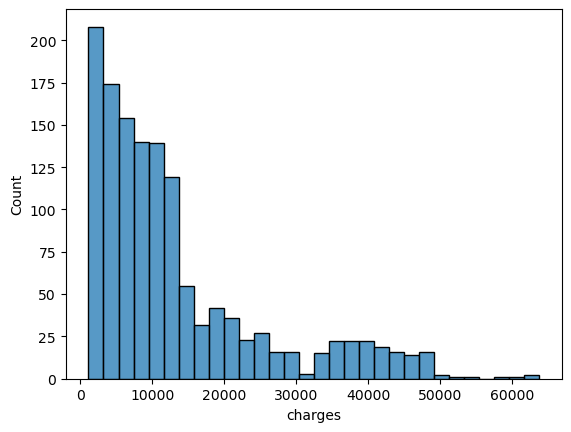

In [40]:
sns.histplot(x='charges',data=df);

<Axes: xlabel='charges'>

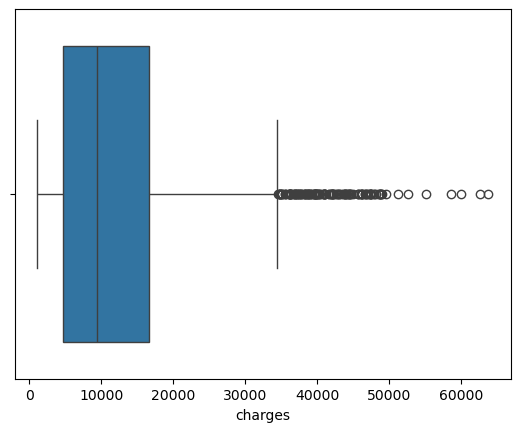

In [42]:
sns.boxplot(x='charges',data=df)

There are outliers in the target variable which will be fixed at a laer stage 

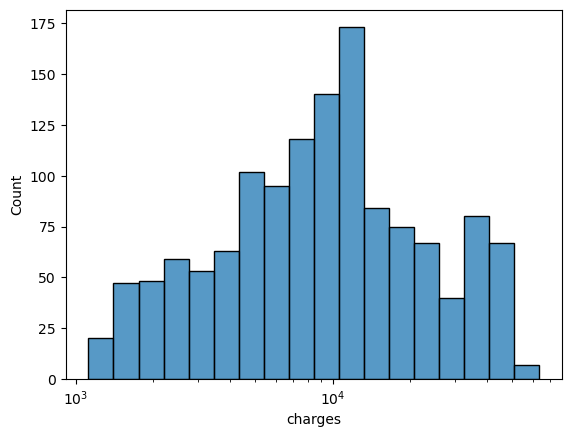

In [45]:
sns.histplot(x='charges',log_scale= True,data=df);

Preparing Data for Modelling 

In [50]:
df_dummy = pd.get_dummies(df,drop_first=True,dtype=int)

In [52]:
df_dummy

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,30.970,3,10600.54830,1,0,1,0,0
1334,18,31.920,0,2205.98080,0,0,0,0,0
1335,18,36.850,0,1629.83350,0,0,0,1,0
1336,21,25.800,0,2007.94500,0,0,0,0,1


In [54]:
from sklearn.model_selection import train_test_split

In [56]:
X = df_dummy.drop('charges',axis=1)
y= df_dummy['charges']

In [58]:
X

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1,18,33.770,1,1,0,0,1,0
2,28,33.000,3,1,0,0,1,0
3,33,22.705,0,1,0,1,0,0
4,32,28.880,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...
1333,50,30.970,3,1,0,1,0,0
1334,18,31.920,0,0,0,0,0,0
1335,18,36.850,0,0,0,0,1,0
1336,21,25.800,0,0,0,0,0,1


In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25)

In [62]:
X_train

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0,1,0,0,1
1079,63,33.660,3,1,0,0,1,0
379,62,31.460,1,1,0,0,1,0
117,29,27.940,1,0,1,0,1,0
1096,51,34.960,2,0,1,0,0,0
...,...,...,...,...,...,...,...,...
135,22,28.050,0,0,0,0,1,0
1166,57,40.370,0,1,0,0,1,0
1273,35,27.610,1,1,0,0,1,0
1098,52,30.875,0,0,0,0,0,0


In [64]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Linear Regression 

In [68]:
linear_model = LinearRegression()
linear_model.fit(X_train,y_train)
ypred_lr = linear_model.predict(X_test)

In [70]:
train_r2=linear_model.score(X_train,y_train)
test_r2 = linear_model.score(X_test,y_test)

In [72]:
train_r2

0.7485768383347415

In [74]:
test_r2

0.7544687103345064

In [76]:
X_train.shape

(1003, 8)

# Ridge Regression

In [88]:
ridge_model = Ridge(alpha=2)
ridge_model.fit(X_train,y_train)
ypred_ridge = ridge_model.predict(X_test)

In [90]:
train_r2=ridge_model.score(X_train,y_train)
test_r2 = ridge_model.score(X_test,y_test)

In [92]:
train_r2

0.7484839966242035

In [94]:
test_r2

0.7536350852173413

# Lasso Regression 

In [113]:
lasso_model = Lasso(alpha=0.5)
lasso_model.fit(X_train,y_train)
ypred_ridge = lasso_model.predict(X_test)

In [115]:
train_r2=lasso_model.score(X_train,y_train)
test_r2 = lasso_model.score(X_test,y_test)

In [117]:
train_r2

0.7485767305821625

In [119]:
test_r2

0.7545029106203762